# 13 - Graph Node Embeddings and Anomaly Detection

**Problem framing.** Two relational questions. First, can we place graph nodes in a continuous space that reflects their connectivity, for visualisation and downstream models? Second, can we flag nodes whose local structure is anomalous - bridges that wire together communities that should be separate? We answer the first with spectral (Laplacian eigenmap) embeddings and the second with an Isolation Forest over structural node features.

**Assumptions.** The graph is undirected with assortative communities; structural features (degree, clustering coefficient, neighbour degree) capture the notion of 'normal' connectivity; and anomalies are rare.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix

sys.path.append(str(Path.cwd() / "src"))

from unsup_lab.graphs import (
    graph_anomaly_scores,
    make_block_graph,
    node_structural_features,
    spectral_node_embedding,
)

## Node embeddings

A stochastic block model with three communities. The spectral embedding places nodes from the same community together, recovering the structure as a continuous 2D layout - without ever seeing the community labels.

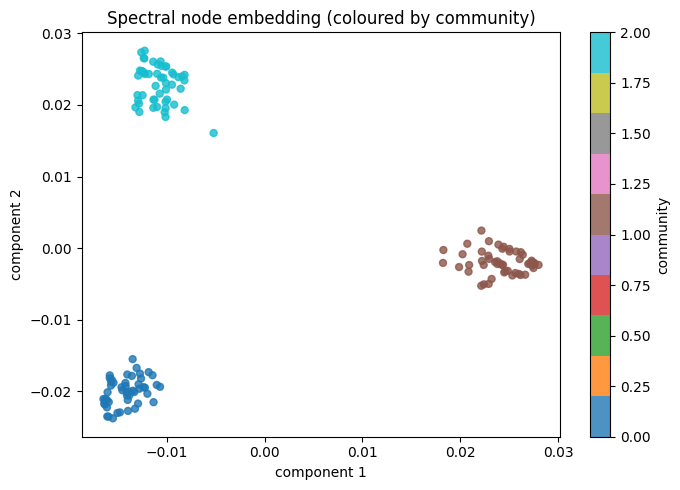

In [2]:
adjacency, communities = make_block_graph(sizes=[50, 50, 50], p_in=0.40, p_out=0.02, random_state=7)
embedding = spectral_node_embedding(adjacency, n_components=2, random_state=0)

fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(embedding[:, 0], embedding[:, 1], c=communities, cmap="tab10", s=25, alpha=0.8)
ax.set_title("Spectral node embedding (coloured by community)")
ax.set_xlabel("component 1")
ax.set_ylabel("component 2")
fig.colorbar(scatter, label="community")
plt.tight_layout()
plt.show()

## Inject anomalous bridge nodes

We rewire six nodes into *bridges* that connect broadly across all three communities - the kind of node that should not exist in a clean community structure.

In [3]:
dense = adjacency.toarray()
n = dense.shape[0]
rng = np.random.default_rng(7)

is_anomaly = np.zeros(n, dtype=bool)
bridges = rng.choice(n, size=6, replace=False)
for node in bridges:
    targets = rng.choice(n, size=28, replace=False)
    dense[node, targets] = 1
    dense[targets, node] = 1
    dense[node, node] = 0
    is_anomaly[node] = True
graph = csr_matrix(dense)

## Detect the anomalies

`graph_anomaly_scores` describes each node by its structural features and scores it with an Isolation Forest. We compare precision-at-k against two baselines: a degree-only ranking and random chance.

In [4]:
k = int(is_anomaly.sum())
scores = graph_anomaly_scores(graph, contamination=0.05, random_state=0)
degree = node_structural_features(graph)["degree"].to_numpy()

structural_top = np.argsort(scores)[::-1][:k]
degree_top = np.argsort(degree)[::-1][:k]
pd.DataFrame(
    [
        {
            "method": "structural Isolation Forest",
            f"precision@{k}": is_anomaly[structural_top].mean(),
        },
        {"method": "degree-only ranking", f"precision@{k}": is_anomaly[degree_top].mean()},
        {"method": "random chance", f"precision@{k}": round(k / n, 3)},
    ]
)

,method,precision@6
0,structural Isolation Forest,0.833333
1,degree-only ranking,1.000000
2,random chance,0.040000


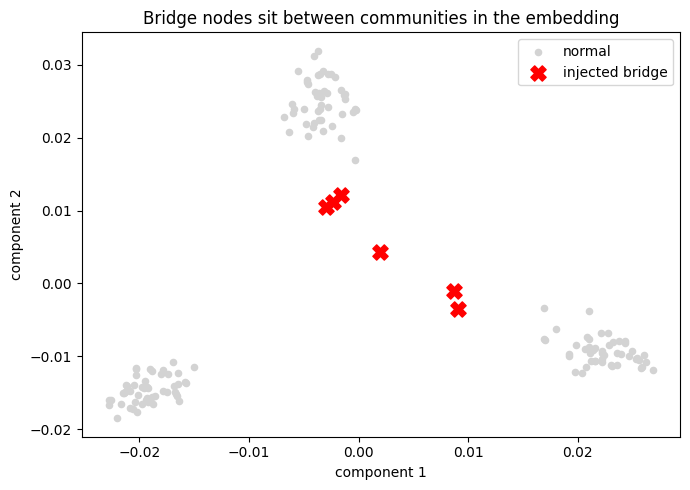

In [5]:
embedding2 = spectral_node_embedding(graph, n_components=2, random_state=0)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    embedding2[~is_anomaly, 0],
    embedding2[~is_anomaly, 1],
    c="lightgray",
    s=20,
    label="normal",
)
ax.scatter(
    embedding2[is_anomaly, 0],
    embedding2[is_anomaly, 1],
    c="red",
    marker="X",
    s=120,
    label="injected bridge",
)
ax.set_title("Bridge nodes sit between communities in the embedding")
ax.set_xlabel("component 1")
ax.set_ylabel("component 2")
ax.legend()
plt.tight_layout()
plt.show()

## Interpretation and limitations

The spectral embedding lays out the communities continuously, and the injected bridges sit between the community clusters rather than inside any one of them. Both the structural Isolation Forest and a degree-only ranking find the bridges far above chance.

Note the honest result: for *high-degree* bridges, degree alone is a perfect detector, and the multi-feature score is slightly noisier. The structural approach earns its keep on anomalies that are **not** simply high-degree - for example a node with normal degree whose neighbours span many communities (a low clustering coefficient), which a degree threshold cannot see. Match the detector to the anomaly you expect.

**Limitations.**

- The three structural features are local; richer anomalies (motifs, temporal patterns) need richer features or learned embeddings.
- Spectral embedding is O(n^2)-O(n^3) and needs the number of components chosen; large graphs need sparse eigensolvers or sampling.
- Isolation Forest assumes anomalies are rare and 'few and different'; a large contaminated fraction breaks that assumption.
- The stochastic block model is an idealisation; real graphs have hubs and heavy-tailed degree distributions that make 'normal' harder to define.